### Dataset Information
We will use the embryonic E18 mouse brain from 10X Multiome as an example.

CellRanger output files can be downloaded from 10X website:\
https://www.10xgenomics.com/datasets/fresh-embryonic-e-18-mouse-brain-5-k-1-standard-1-0-0

And we followed preprocessing methos provided from Li et al., 

### Cell Type Annotations
The annotation file is provided as `data/mousebrain_cell_annotations.tsv` in the GitHub repository

In [25]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from scipy import sparse
import anndata
import seaborn as sns
import scvelo as scv

In [2]:
import matplotlib
matplotlib.rcParams.update({'font.size': 12})
matplotlib.rcParams.update({'figure.facecolor': 'white'})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

matplotlib.rcParams['ytick.labelright'] = False
matplotlib.rcParams['ytick.labelleft'] = True
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.left'] = True

In [3]:
import sys
sys.path.append("../src/")
import MoFlow as mf

In [4]:
scvelo = anndata.read_h5ad(
    '../data/Mouse_brain/adata_scvelo.h5ad')
multivelo = anndata.read_h5ad(
    '../data/Mouse_brain/adata_multivelo.h5ad')
celldancer = anndata.read_h5ad(
    '../data/Mouse_brain/adata_celldancer.h5ad')

In [5]:
adata_out = anndata.read_h5ad(
    '../data/Mouse_brain/adata_moflow.h5ad')

In [6]:
#labels = pd.read_csv('../temps/250222_mousebrain_cluster.csv', index_col=0)
labels = pd.read_csv('../temps/250325_mousebrain_cluster.csv', index_col=0)

saving figure to file ../figures/fig6A_moflow.svg


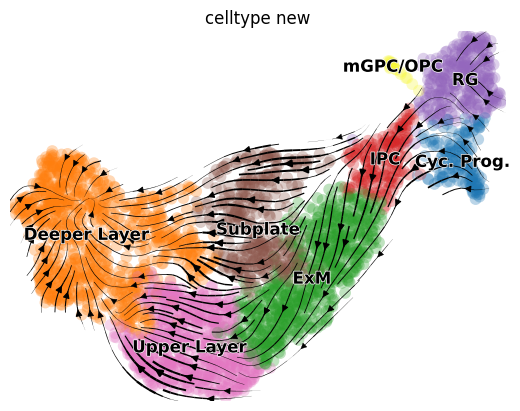

In [7]:
scv.pl.velocity_embedding_stream(adata_out,
                                 vkey='velo_s',
                                 color='celltype_new',
                                 save='../figures/fig6A_moflow.svg')

saving figure to file ../figures/fig6A_time.pdf


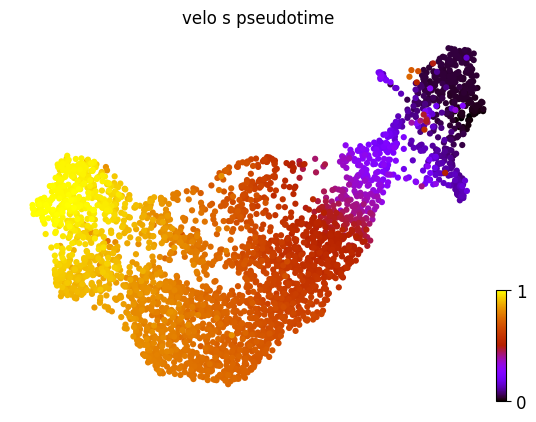

In [8]:
scv.pl.scatter(adata_out, color='velo_s_pseudotime',
               cmap='gnuplot', size=80,
save='../figures/fig6A_time.pdf')

saving figure to file ../figures/fig6A_scvelo.svg


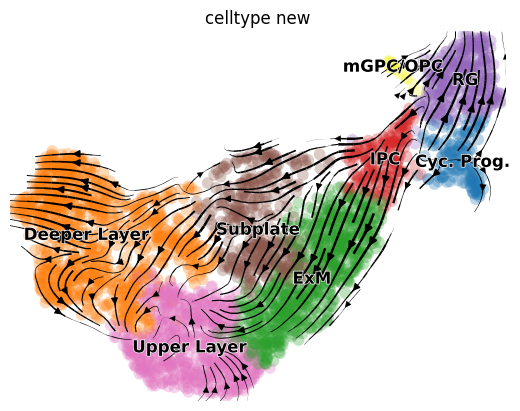

In [9]:
scv.pl.velocity_embedding_stream(scvelo,
                                 color='celltype_new',
                                 save='../figures/fig6A_scvelo.svg')

saving figure to file ../figures/fig6A_multivelo.svg


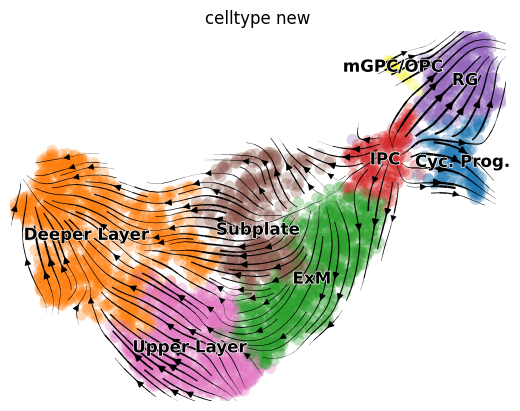

In [10]:
scv.pl.velocity_embedding_stream(multivelo,
                                 vkey='velo_s_norm',
                                 color='celltype_new',
                                 save='../figures/fig6A_multivelo.svg')

saving figure to file ../figures/fig6A_celldancer.svg


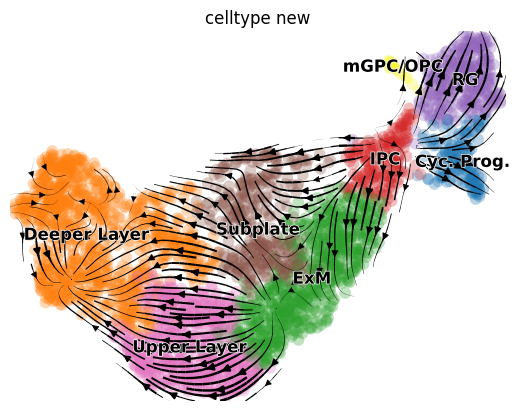

In [11]:
scv.pl.velocity_embedding_stream(celldancer,
                                 vkey='velo_s',
                                 color='celltype_new',
                                 save='../figures/fig6A_celldancer.svg')

In [12]:
marker_genes_dict ={
    'Cyc. Prog.' : ['Top2a', 'Clspn', 'Aurka', 'Mki67'],  

    # **Radial Glia (RG)**
    'RG' : ['Atp1a2', 'Vim', 
    'Fgfr3', 'Fabp7', #early RG
    'Cd9', 'Tnc', 'Slc1a3',  # late RG
    # **Outer Radial Glia (oRG)**
    'Moxd1', 'Hopx', 'Mt3', 'Tnc', ],

    # **mGPC (Multipotent Glial Progenitor Cells)**
    'mGPC/OPC': ['Ascl1', 'Olig2', 'Pdgfra', 'Egfr', 'Cspg4'], 
    
    'IPC': ['Eomes', 'Pax6'], #IPC
    #['Eomes', 'Dcx', 'Tubb3', 'Pax6']
    'ExM': ['Dcx', 'Tubb3', ],
    
    # **Subplate Neurons**
    'Subplate' : ['Nr4a2', 'Crym', 'Ldb2', 'Sox5', 'Tbr1'], 

    # **Glutamatergic Neurons**
    'Upper Layer': ['Satb2', 'Rorb', 'Cux1', 'Cux2', 'Tle4'], #upper layer
    'Deeper Layer' : ['Bcl11b', 'Fezf2',  'Foxp2', 'Tbr1'], #deeper layer

    
}

In [16]:
sc.tl.dendrogram(adata_out, groupby='celltype_new', 
                 var_names = [g for c, g in marker_genes_dict.items()]
                )

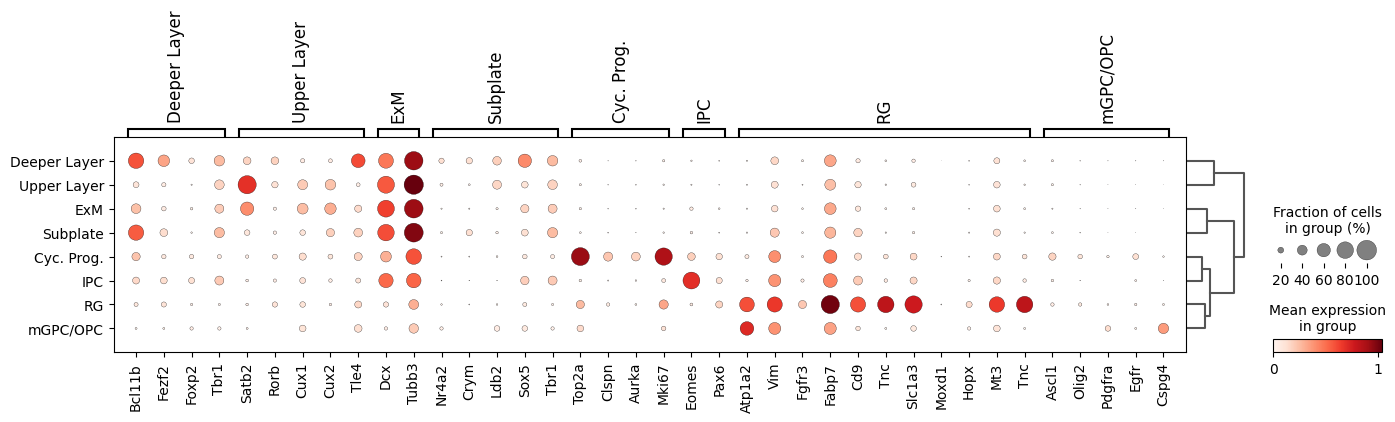

In [13]:
dp = sc.pl.dotplot(adata_out, marker_genes_dict, "celltype_new", dendrogram=True, return_fig=True)
dp.savefig('../figures/fig6A_S_dot.pdf')


In [6]:
cluster_edges = (('Cyc. Prog.', 'RG'), ('Cyc. Prog.', 'IPC'), ('RG', 'IPC'),
 ('IPC',' Subplate'), ('IPC', 'ExM'),
 ('Subplate', 'Deeper Layer'),  ('Subplate', 'Upper Layer'),
 ('ExM', 'Subplate'), ('ExM', 'Deeper Layer'),('ExM', 'Upper Layer'))

In [7]:
scv.pp.neighbors(celldancer, method='sklearn')
scv.pp.neighbors(multivelo, method='sklearn')
scv.pp.neighbors(adata_out, method='sklearn')
scv.pp.neighbors(scvelo, method='sklearn')

computing neighbors


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


    finished (0:00:27) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing neighbors
    finished (0:00:04) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing neighbors
    finished (0:00:05) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing neighbors
    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)


In [8]:
adata_out.obsm

AxisArrays with keys: X_pca, X_umap, velo_s_umap

In [9]:
cbdir = {}
cbdir['mosync'] = mf.cross_boundary_correctness(adata_out, 'celltype_new', 'velo_s', cluster_edges,
                                          True, 'X_umap')
cbdir['scvelo'] = mf.cross_boundary_correctness(scvelo, 'celltype_new', 'velocity', cluster_edges,
                                          True, 'X_umap')
cbdir['celldancer'] = mf.cross_boundary_correctness(celldancer, 'celltype_new', 'velo_s', cluster_edges,
                                          True, 'X_umap')
cbdir['multivelo'] = mf.cross_boundary_correctness(multivelo, 'celltype_new', 'velo_s_norm', cluster_edges,
                                          True, 'X_umap')

In [10]:
cbdir_ = []
for k in cbdir.values():
    temp = {}
    for c, s in k.items():
        s = np.mean(s)
        temp[c] = s
    cbdir_.append(temp)
    
cbdir_ = pd.DataFrame(cbdir_, index=cbdir.keys()).fillna(0)

In [11]:
cbdir_

,"(Cyc. Prog., RG)","(Cyc. Prog., IPC)","(RG, IPC)","(IPC, Subplate)","(IPC, ExM)","(Subplate, Deeper Layer)","(Subplate, Upper Layer)","(ExM, Subplate)","(ExM, Deeper Layer)","(ExM, Upper Layer)"
mosync,0.198124,0.852316,0.771517,0.0,0.845420,0.890671,0.305153,0.071895,0.657090,0.760507
scvelo,0.531815,-0.184732,-0.551593,0.0,0.787139,0.303102,0.829333,0.039027,0.367163,0.606667
celldancer,0.210124,-0.737721,-0.693721,0.0,0.729345,0.764514,-0.243472,0.130583,0.681139,0.483144
multivelo,0.188864,-0.914284,-0.949898,0.0,0.583043,0.836547,0.261118,0.011619,0.844477,0.688404


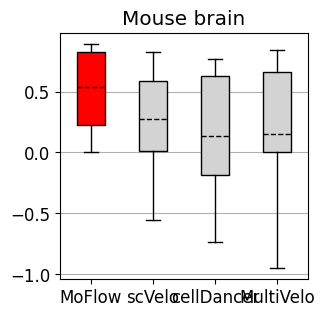

In [12]:
fig, ax = plt.subplots(figsize=(3.2, 3.2))
bplot = ax.boxplot(cbdir_.T,
            medianprops=dict(linewidth=0),
            meanline=True, 
            showmeans=True, 
            #width=.5, 
            meanprops=dict(color='black'), 
            patch_artist=True,
            showfliers=False)
colors = ['red', 'lightgrey', 'lightgrey', 'lightgrey']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color=color)
ax.set_xticklabels(['MoFlow', 'scVelo', 'cellDancer', 'MultiVelo'])
plt.title('Mouse brain')
plt.grid(axis='y')
fig.savefig('../figures/fig6B_cbdir.pdf')

In [44]:
from sklearn.cluster import KMeans

In [15]:
kmeans = KMeans(n_clusters=18)
kmeans.fit(adata_out.layers['s'].T)

KMeans(n_clusters=18)

In [26]:
labels = pd.DataFrame(kmeans.labels_, index=adata_out.var_names, columns=['label'])

In [38]:
labeldict={0: 10,
           1: 3,
           2: 2,
           3: 9,
           4: 0,
           5: 11,
           6: 5,
           7: 1,
           8: 3,
           9: 7,
           10: 8,
           11: 1,
           12: 9,
           13: 4,
           14: 1,
           15: 6,
           16: 1,
           17: 5,
               
}

In [45]:
labels_ = labels.copy()
labels_['label'] = labels_['label'].map(labeldict)

In [61]:
labels_.to_csv('../temps/250325_mousebrain_cluster.csv')

In [10]:
labels = pd.read_csv('../temps/250325_mousebrain_cluster.csv',
                     index_col=0)

In [47]:
scv.tl.score_genes_cell_cycle(adata_out)

calculating cell cycle phase
-->     'S_score' and 'G2M_score', scores of cell cycle phases (adata.obs)


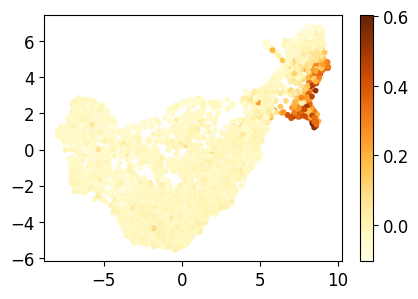

In [48]:
fig, ax = plt.subplots(figsize=(4.8, 3.2))
im = plt.scatter(
    x = adata_out.obsm['X_umap'][:, 0],
    y = adata_out.obsm['X_umap'][:, 1],
    c= adata_out.obs['G2M_score'].ravel(),
    cmap='YlOrBr', s=10
    )
plt.colorbar(im)
fig.savefig('../figures/fig6A_g2m.pdf')

In [8]:
model_df = mf.eval.get_genescore(adata_out)

In [9]:
genes = list(set(model_df.index) & set(labels.index))

NameError: name 'labels' is not defined

In [ ]:
labels = labels.loc[genes]
model_df = model_df.loc[genes]

In [ ]:
genelist = set(adata_out.var_names) & set(multivelo.var_names)
adata_out_ = adata_out[:, adata_out.var_names.isin(genelist)]
multivelo_ = multivelo[:, multivelo.var_names.isin(genelist)]
model_df_ = model_df.loc[ multivelo_.var_names.values]

In [ ]:
model_df_['fit_model'] = multivelo_.var['fit_model']
model_df_['fit_direction'] = multivelo_.var['fit_direction']

In [ ]:
from scipy import stats

In [ ]:
stats.ttest_ind(model_df_[model_df_['fit_model']==1]['m1'], 
                model_df_[model_df_['fit_model']==2]['m1'],
                equal_var=False, alternative='greater')

In [ ]:
stats.ttest_ind(model_df_[model_df_['fit_model']==1]['m2'], 
                model_df_[model_df_['fit_model']==2]['m2'],
                equal_var=False, alternative='less')

In [ ]:
stats.ttest_ind(model_df_[model_df_['fit_model']==1]['off'], 
                model_df_[model_df_['fit_model']==2]['off'],
                equal_var=False, alternative='less')

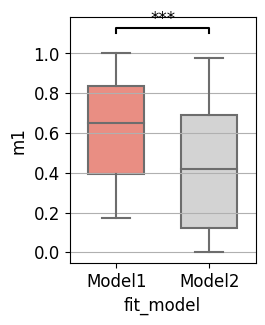

In [30]:
fig, ax = plt.subplots(figsize=(2.4, 3.2))
sns.boxplot(model_df_, y='m1', x='fit_model',
             palette=['salmon', 'lightgrey'],  width=.6, whis=.5, showfliers=False)
ax.grid(axis='y')

ylim = ax.get_ylim()
yrange = ylim[1] - ylim[0]
h = 0.02*yrange
offset = 0.05 * yrange
y = ylim[1] + offset
x1, x2 = 0, 1
ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='black')
ax.text((x1+x2)/2, y+h*2, '***', ha='center')

ax.set_xticklabels(['Model1', 'Model2'])

fig.savefig('../figures/fig6D_mvmodel_m1.pdf')

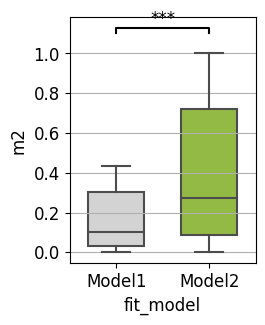

In [33]:
fig, ax = plt.subplots(figsize=(2.4, 3.2))
sns.boxplot(model_df_, y='m2', x='fit_model',
             palette=['lightgrey', 'yellowgreen'],  width=.6, whis=.5, showfliers=False)
ax.grid(axis='y')
ax.set_xticklabels(['Model1', 'Model2'])

ylim = ax.get_ylim()
yrange = ylim[1] - ylim[0]
h = 0.02*yrange
offset = 0.05 * yrange
y = ylim[1] + offset
x1, x2 = 0, 1
ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='black')
ax.text((x1+x2)/2, y+h*2, '***', ha='center')

ax.set_xticklabels(['Model1', 'Model2'])

fig.savefig('../figures/fig6D_mvmodel_m2.pdf')

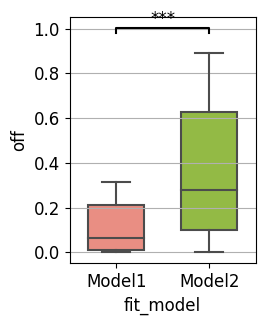

In [34]:
fig, ax = plt.subplots(figsize=(2.4, 3.2))
sns.boxplot(model_df_, y='off', x='fit_model',
             palette=['salmon', 'yellowgreen'], width=.6, whis=.5, showfliers=False)
ax.grid(axis='y')
ax.set_xticklabels(['Model1', 'Model2'])

ylim = ax.get_ylim()
yrange = ylim[1] - ylim[0]
h = 0.02*yrange
offset = 0.05 * yrange
y = ylim[1] + offset
x1, x2 = 0, 1
ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='black')
ax.text((x1+x2)/2, y+h*2, '***', ha='center')

ax.set_xticklabels(['Model1', 'Model2'])

fig.savefig('../figures/fig6D_mvmodel_off.pdf')

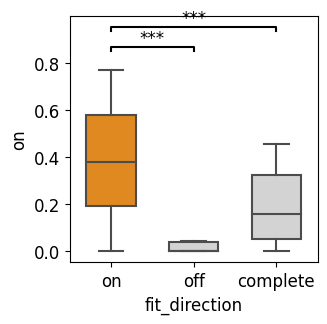

In [35]:
fig, ax = plt.subplots(figsize=(3.2, 3.2))
sns.boxplot(model_df_, y='on', x='fit_direction',
             palette=['darkorange', 'lightgrey', 'lightgrey'], 
             order=['on', 'off', 'complete'], width=.6, whis=.5, showfliers=False)
ax.grid(axis='y')

ylim = ax.get_ylim()
yrange = ylim[1] - ylim[0]
h = 0.02*yrange
offset = 0.05 * yrange
y = ylim[1] + offset
x1, x2 = 0, 1
ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='black')
ax.text((x1+x2)/2, y+h*2, '***', ha='center')

x1, x2 = 0, 2
y = y+h*5
ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='black')
ax.text((x1+x2)/2, y+h*2, '***', ha='center')


ax.grid(axis='y')
fig.savefig('../figures/fig6D_S_mvmodel_diron.pdf')

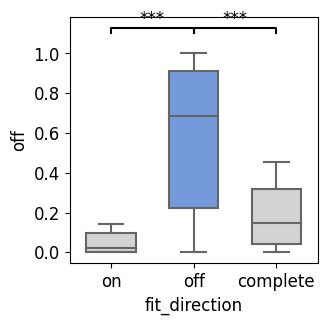

In [36]:
fig, ax = plt.subplots(figsize=(3.2, 3.2))
sns.boxplot(model_df_, y='off', x='fit_direction',
            palette=['lightgrey', 'cornflowerblue', 'lightgrey'], 
             order=['on', 'off', 'complete'], width=.6, whis=.5, showfliers=False)
ax.grid(axis='y')

ylim = ax.get_ylim()
yrange = ylim[1] - ylim[0]
h = 0.02*yrange
offset = 0.05 * yrange
y = ylim[1] + offset
x1, x2 = 0, 1
ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='black')
ax.text((x1+x2)/2, y+h*2, '***', ha='center')

x1, x2 = 1, 2
ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='black')
ax.text((x1+x2)/2, y+h*2, '***', ha='center')



ax.grid(axis='y')
fig.savefig('../figures/fig6D_S_mvmodel_diroff.pdf')

In [3]:
goterm = []
for i in range(12):
    gobp = pd.read_csv(f'../temps/mb_cluster{i}.txt', sep='\t')
    gobp['cluster'] = i
    goterm.append(gobp.head(10))


In [4]:
goterm_ = pd.concat(goterm)

In [5]:
shortterm = []
for t in goterm_['Term']:
    if 'cell division' in t:
        shortterm.append('Cell division')
    elif 'cell cycle' in t:
        shortterm.append('Cell division')
    elif 'proliferation' in t:
        shortterm.append('Proliferation')
    elif 'migration' in t:
        shortterm.append('Migration')
    elif ('chromosome segregation' in t) or ('chromatin organization' in t) or ('regeneration' in t):
        shortterm.append('Cell division')
    elif 'DNA repair' in t:
        shortterm.append('DNA repair')
    elif 'DNA damage' in t:
        shortterm.append('DNA repair')
    elif ('mitotic' in t) or ('mitosis' in t):
        shortterm.append('Mitosis')
    
    elif (('response' in t ) & ('stress' in t)) or ('hypoxia' in t) or ('mechanical stimulus' in t) or ('response to metal ion' in t) or ('apoptotic' in t):
        shortterm.append('Response to stimulus')
    elif ('metabolic' in t):
        shortterm.append('Cell environment')
    elif ('signal transduction') in t or ('pathway' in t) or ('cascade' in t):
        shortterm.append('Signal transduction') 
    elif ('angiogenesis' in t) or ('blood vessel' in t):
        shortterm.append('Development')
    elif ('synapse' in t ) or ('synaptic' in t):
        if ('organization' in t ) or ('assembly' in t):
            shortterm.append('Neural & synaptic function')
        elif ('translation' in t) or ('protein localization' in t):
            shortterm.append('Neural & synaptic function')
        elif ('potentiation' in t) or ('transmission' in t) or ('potential' in t) or ('long-term synaptic depression' in t):
            shortterm.append('Neural & synaptic function')        
    
    elif ('development' in t) or ('animal organ morphogenesis' in t) or ('stem cell' in t):
        shortterm.append('Development')
    elif ('memory' in t) or ('visual' in t):
        shortterm.append('Neural & synaptic function')
    elif 'axon' in t:
        shortterm.append('Axon development')
    elif ('behavior' in t) or ('startle' in t) or ('GO:0050885~neuromuscular process controlling balance' in t):
        shortterm.append('Neural & synaptic function')
    elif ('dichotomous subdivision of terminal units involved in salivary gland branching' in t):
        shortterm.append('Development')
    elif ('dorsal/ventral pattern formation' in t):
        shortterm.append('Cell division')
    elif 'neuronal action potential' in t:
        shortterm.append('Neural & synaptic function')     
    elif ('cell adhesion' in t) or ('extracellular matrix' in t):
        shortterm.append('Cell environment')     
    elif 'transcription' in t:
        shortterm.append('Gene expression & processing')
    elif (('processing' in t) & ('RNA' in t)) | ('transport' in t) | ('splicing' in t) | ('export' in t):
        shortterm.append('Gene expression & processing')
    elif ('translation' in t) or ('ribosomal' in t) or ('proteolysis' in t) or ('protein' in t):
        shortterm.append('Gene expression & processing')
    elif ('microtubule' in t) or ('vesicle fusion' in t):
        shortterm.append('Cell environment')  
    elif 'pain' in t:
        shortterm.append('Response to stimulus')  
        
    else:
        shortterm.append(t.split('~')[1])
        #print(t)

In [6]:
goterm_['short term'] = shortterm

In [12]:
with pd.ExcelWriter('../temps/fig6_go.xlsx') as writer:
    goterm_.to_excel(writer, sheet_name=f'mousebrain_cluster_GO', index=False)

In [42]:
pivot  = pd.pivot_table(goterm_, index='short term', columns='cluster', values='PValue', aggfunc='min').fillna(1)

In [43]:
pivot = -np.log10(pivot)

In [44]:
pivot = pivot.drop(['biological_process', 'cardiac conduction', 'glial cell fate specification'],axis=0)

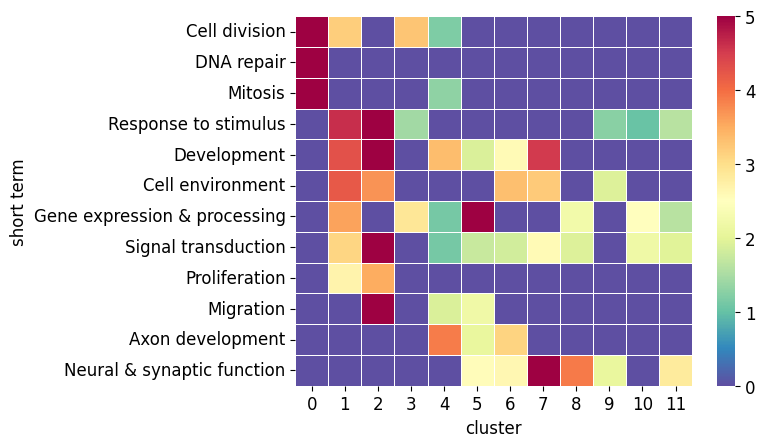

In [45]:
sns.heatmap(pivot.sort_values(by=list(range(12)), ascending=False),
            cmap="Spectral_r", vmax=5, linewidth=.5)
plt.savefig('../figures/fig6G_GO.pdf')

Because of dependency, aggregation and go term analysis is done at python>3.9 environment

In [46]:
import scanpy as sc

In [7]:
adata_norma = adata_out.copy()
adata_norma.layers['alpha'] -= adata_norma.layers['alpha'].min(axis=0)
adata_norma.layers['alpha'] /= adata_norma.layers['alpha'].max(axis=0)


In [8]:
agg_c = sc.get.aggregate(adata_norma, by='celltype', axis=0, layer='c', func=['mean', 'var'])
agg_a = sc.get.aggregate(adata_norma, by='celltype', axis=0, layer='alpha', func=['mean', 'var'])

In [9]:
agg_df = pd.DataFrame({
          "c": np.std(agg_c.layers['mean'], axis=0),
          "a": np.std(agg_a.layers['mean'], axis=0)},
                      index=adata_out.var_names)

In [10]:
agg_df['label'] = labels['label']

In [11]:
import gseapy as gp

In [12]:
gene_sets="GO_Biological_Process_2025"

In [83]:
agg_df_upcase = agg_df.copy()
agg_df_upcase.index = np.char.upper(agg_df.index.values.astype('str'))

In [84]:
gsea_res_a = gp.prerank(
    rnk = agg_df_upcase['a'],
    gene_sets=gene_sets,
    organism="Mouse",
    outdir=None
    
    
)
gsea_res_c = gp.prerank(
    rnk = agg_df_upcase['c'],
    gene_sets=gene_sets, 
    organism="Mouse",
    outdir=None
)

2025-05-08 11:30:29,521 [WARNING] Duplicated values found in preranked stats: 1.42% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [85]:
ax = gp.dotplot(gsea_res_a.res2d, column="FDR q-val", top_term=5,
             figsize=(2.4, 2.4), title='alpha', vmax=2.9, vmin=2.8,
             ofname='../figures/fig6I_S_gsea_a.pdf'
)

In [86]:
ax = gp.dotplot(gsea_res_c.res2d, column="NOM p-val", top_term=5,
             figsize=(2.4, 2.4), title='chromatin accessibility', 
             ofname='../figures/fig6I_S_gsea_c.pdf'
)

In [101]:
gsea_res_a = gp.prerank(
    rnk = agg_df_upcase[agg_df_upcase['label']==0]['a'],
    gene_sets=gene_sets,
    organism="Mouse",
    outdir=None, 
    
)

gsea_res_c = gp.prerank(
    rnk = agg_df_upcase[agg_df_upcase['label']==0]['c'],
    gene_sets=gene_sets,
    organism="Mouse",
    outdir=None, 
    
)

2025-05-08 11:33:49,122 [WARNING] Duplicated values found in preranked stats: 0.42% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


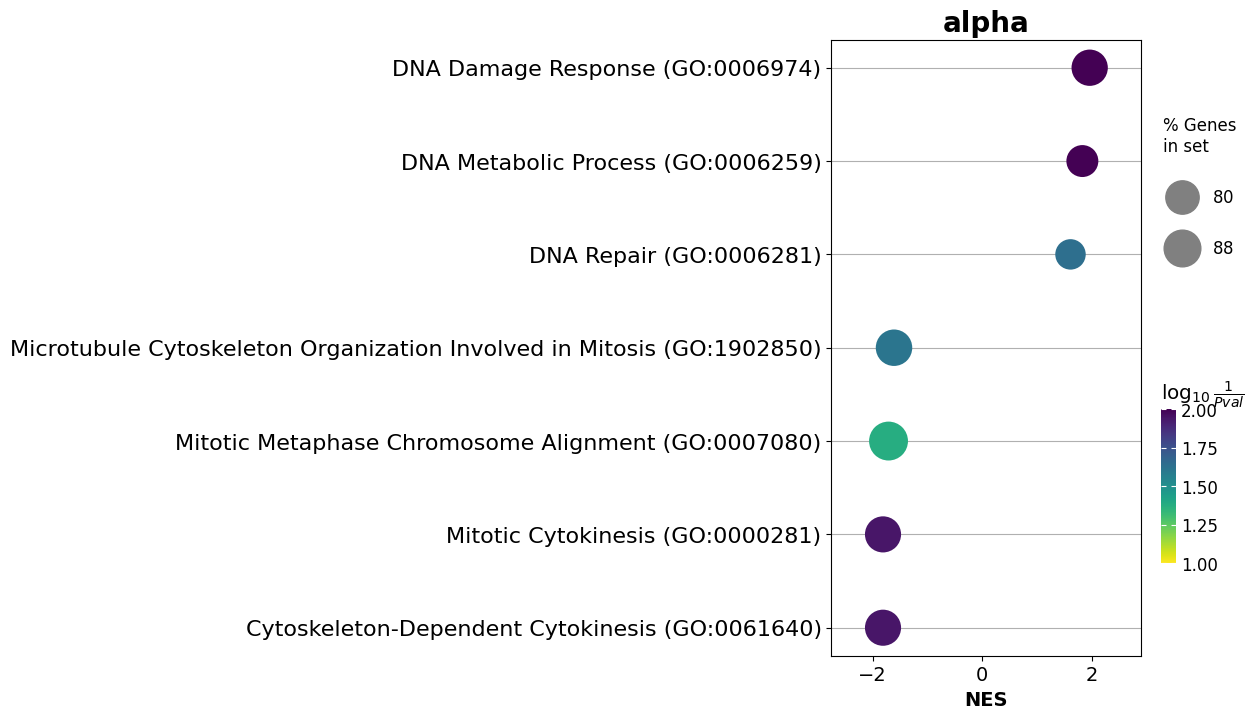

In [102]:
ax = gp.dotplot(gsea_res_a.res2d, column="NOM p-val", top_term=10,
             figsize=(5,8), title='alpha', 
             #ofname='../figures/fig6I_gsea_0a.pdf'
)

In [104]:
ax = gp.dotplot(gsea_res_c.res2d, column="NOM p-val", top_term=5,
             figsize=(2.4, 2.4), title='chromatin accessibility',
             
             ofname='../figures/fig6I_S_gsea_0c.pdf'
)

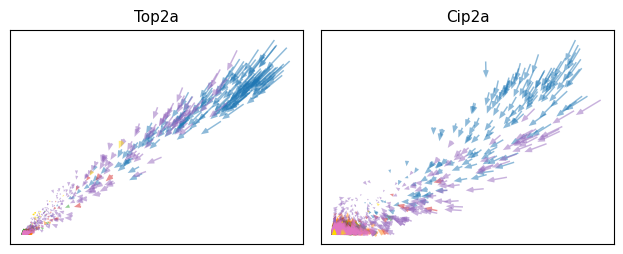

In [21]:
fig, ax = mf.scatter_gene(adata_out, 
                          ['Top2a', 'Cip2a',
                                      ],
                          color_by='celltype_new',
                          velocity_arrows=True, axis_on=False)
fig.savefig('../figures/fig6J.pdf')

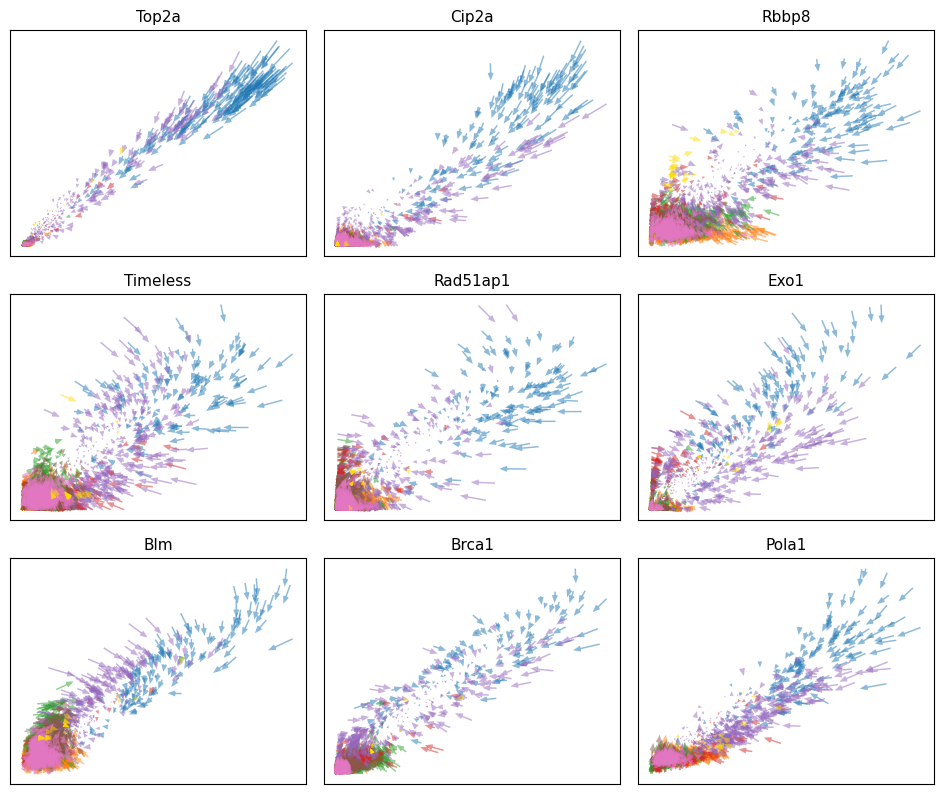

In [24]:
fig, ax = mf.scatter_gene(adata_out, 
                          ['Top2a', 'Cip2a', 'Rbbp8', 'Timeless', 'Rad51ap1', 'Exo1',
                           'Blm', 'Brca1', 'Pola1'
                                      ],
                          color_by='celltype_new', n_cols=3,
                          velocity_arrows=True, axis_on=False)
fig.savefig('../figures/fig6J_S_mf.pdf')

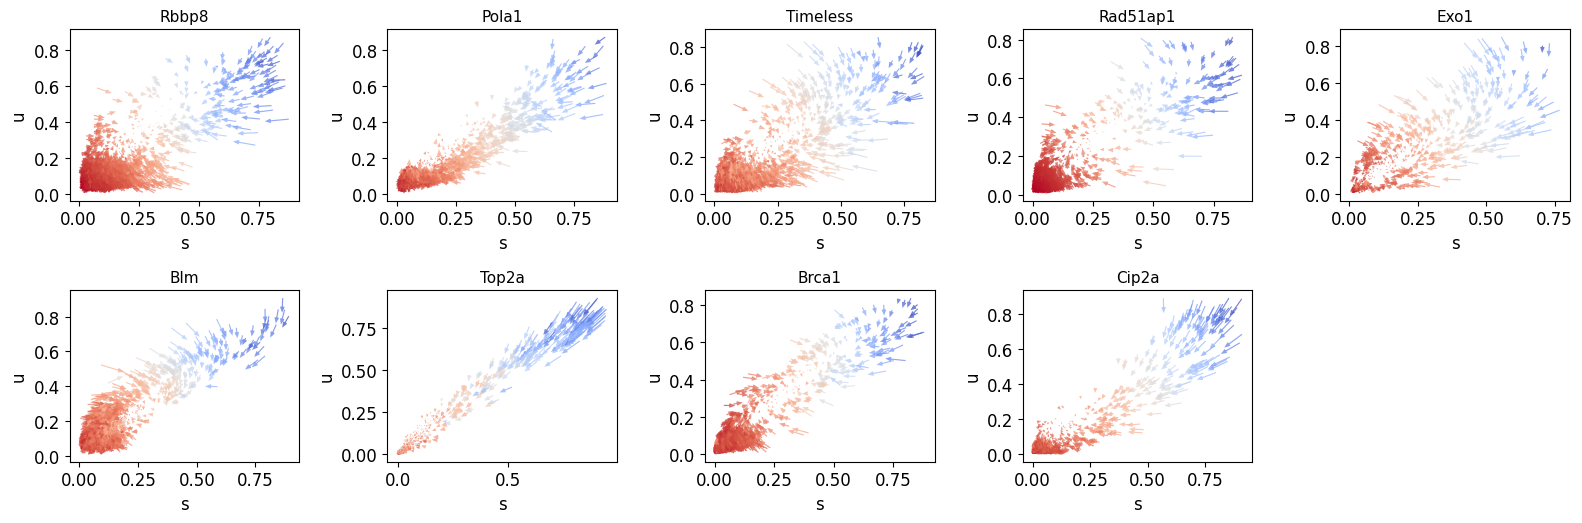

In [7]:
fig, ax = mf.scatter_gene(adata_out, 
                          ['Rbbp8', 'Pola1', 'Timeless', 'Rad51ap1', 'Exo1',
                           'Blm', 'Top2a', 'Brca1', 'Cip2a'
                                      ],
                          color_by='alpha',
                          velocity_arrows=True)

In [18]:
multivelo.layers['Mc'] = multivelo.layers['ATAC']
multivelo.layers['velo_c'] = multivelo.layers['velo_chrom']

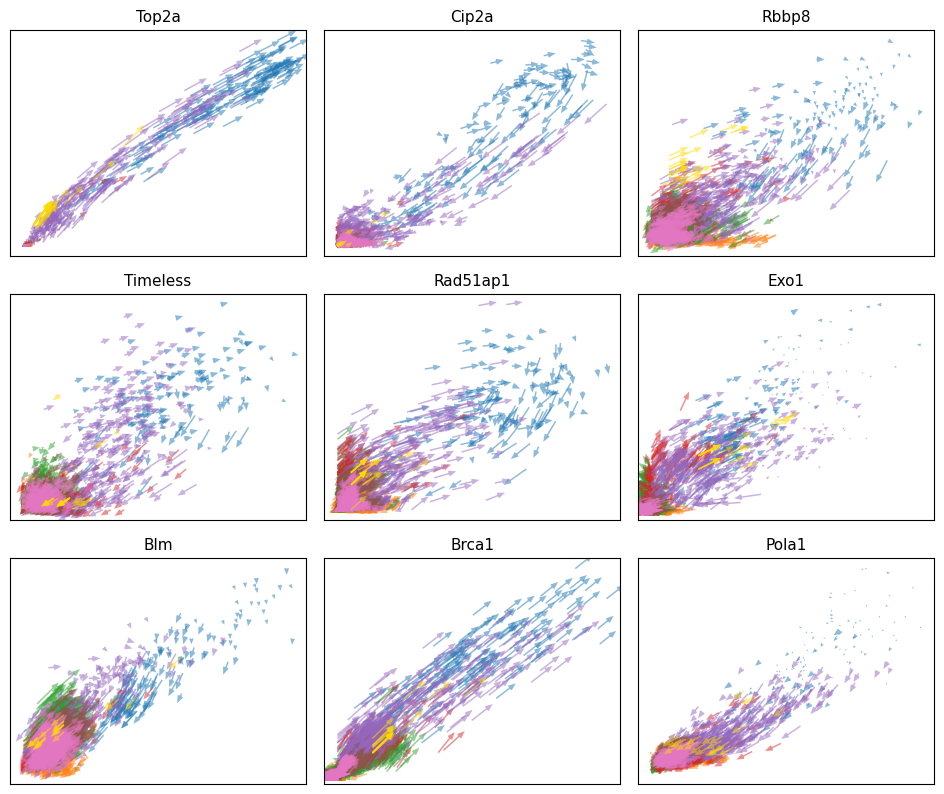

In [23]:
fig, ax = mf.scatter_gene(multivelo, 
                          ['Top2a', 'Cip2a', 'Rbbp8', 'Timeless', 'Rad51ap1', 'Exo1',
                           'Blm', 'Brca1', 'Pola1'
                                      ], n_cols=3,
                          color_by='celltype_new',
                          velocity_arrows=True, axis_on=False)
fig.savefig('../figures/fig6J_S_mv.pdf')